--- Model Comparison ---
              Model      AUC  Brier Score
           LightGBM 0.776150     0.135329
Logistic Regression 0.720255     0.142449

--- Logistic Regression Detailed Report ---
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4667
           1       0.65      0.35      0.45      1326

    accuracy                           0.81      5993
   macro avg       0.74      0.65      0.67      5993
weighted avg       0.79      0.81      0.79      5993



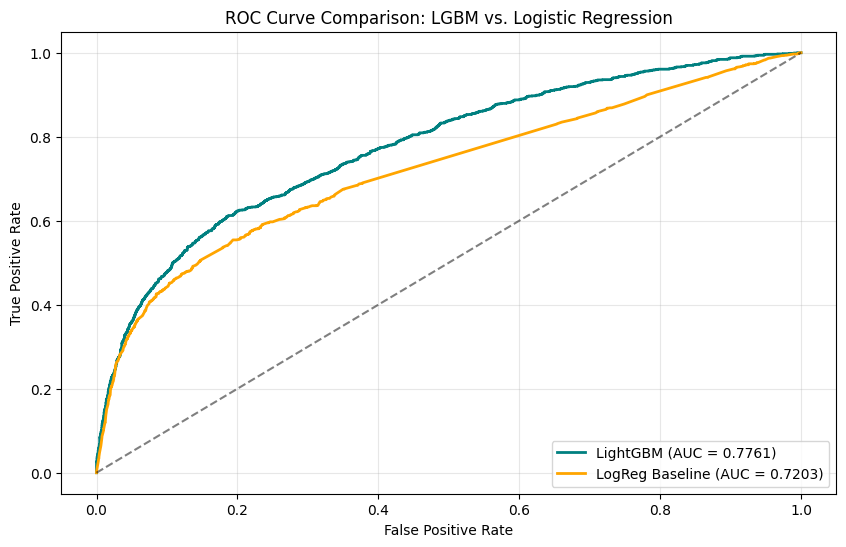

In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, 
    brier_score_loss, 
    classification_report, 
    roc_curve, 
    auc
)



LGBM_MODEL_PATH = 'Models/lgbm_credit_model.txt'
FEAT_PATH = 'Models/feature_columns.pkl'


LR_MODEL_PATH = 'Models/logreg_baseline_model.joblib'
LR_SCALER_PATH = 'Models/logreg_scaler.joblib'

DATA_PATH = 'data/credit_data_test.csv'
TARGET = 'default payment next month'


test_df = pd.read_csv(DATA_PATH)
y_test = test_df[TARGET]

# LGBM Evaluation 
model_lgbm = lgb.Booster(model_file=LGBM_MODEL_PATH)
lgbm_features = joblib.load(FEAT_PATH)

X_test_lgbm = test_df[lgbm_features].copy()
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cat_cols:
    if col in X_test_lgbm.columns:
        X_test_lgbm[col] = X_test_lgbm[col].astype('category')

y_prob_lgbm = model_lgbm.predict(X_test_lgbm)

#  Logistic Regression Evaluation 
model_lr = joblib.load(LR_MODEL_PATH)
scaler_lr = joblib.load(LR_SCALER_PATH)

X_test_lr = test_df[lgbm_features].copy()
X_test_lr = pd.get_dummies(X_test_lr, columns=cat_cols, drop_first=True)

expected_cols = scaler_lr.feature_names_in_
X_test_lr = X_test_lr.reindex(columns=expected_cols, fill_value=0)

X_test_lr_scaled_array = scaler_lr.transform(X_test_lr)


X_test_lr_scaled = pd.DataFrame(
    X_test_lr_scaled_array, 
    columns=expected_cols, 
    index=X_test_lr.index
)


y_prob_lr = model_lr.predict_proba(X_test_lr_scaled)[:, 1]

# comparison 
results = pd.DataFrame({
    'Model': ['LightGBM', 'Logistic Regression'],
    'AUC': [roc_auc_score(y_test, y_prob_lgbm), roc_auc_score(y_test, y_prob_lr)],
    'Brier Score': [brier_score_loss(y_test, y_prob_lgbm), brier_score_loss(y_test, y_prob_lr)]
})

print("--- Model Comparison ---")
print(results.to_string(index=False))

print("\n--- Logistic Regression Detailed Report ---")
y_pred_lr = (y_prob_lr >= 0.5).astype(int)
print(classification_report(y_test, y_pred_lr))

# graph
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {results.iloc[0]["AUC"]:.4f})', color='teal', lw=2)
plt.plot(fpr_lr, tpr_lr, label=f'LogReg Baseline (AUC = {results.iloc[1]["AUC"]:.4f})', color='orange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) 

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: LGBM vs. Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()